In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GBP_FX_BoE_10y.csv"
TARGET = "GBP-CNY"

## Data Loading and Preprocessing

In [11]:
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import prepare_fx_data
from fx_forecasting.data.inspect import inspect_data

df, feature_columns = load_fx_csv(DATA_PATH, date_col='Date')

# Assume LSTM model
X_train, y_train, X_test, y_test, scaler = prepare_fx_data(
    df,
    target_col=TARGET,
    test_ratio=0.2,
    add_returns=True,
    add_ma=False,
    add_volatility=False,
    scale=True,
    scaler_type="standard",
    make_windows=True,
    lookback=30
)

# feature_columns = [c for c in columns if c != TARGET]
print(feature_columns)

['GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']


/Users/apple/COMP0197-group-project/src/fx_forecasting/data/load.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[date_col], errors="coerce")


In [12]:
# Inspect Data
inspect_data(df)


Shape: (2779, 7)

Columns:
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']

First rows:
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338
2 2015-01-06   9.4244   1.5170   1.2727  180.0831  1670.4901   1.5287
3 2015-01-07   9.3582   1.5063   1.2762  179.9275  1661.7351   1.5327
4 2015-01-08   9.3724   1.5082   1.2789  180.5014  1654.6764   1.5363

Data types:
timestamp    datetime64[us]
GBP-CNY             float64
GBP-USD             float64
GBP-EUR             float64
GBP-JPY             float64
GBP-KRW             float64
GBP-CHF             float64
dtype: object

Missing values:
timestamp    0
GBP-CNY      0
GBP-USD      0
GBP-EUR      0
GBP-JPY      0
GBP-KRW      0
GBP-CHF      0
dtype: int64

Date range:
Start: 2015-01-02 00:00:00
End: 2025-12-31 00:00:00

Observed time gaps:
timestamp
1 days

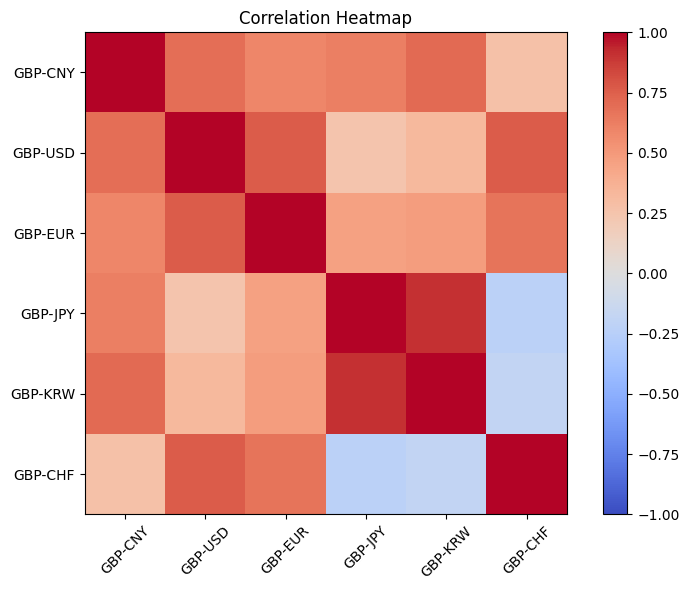

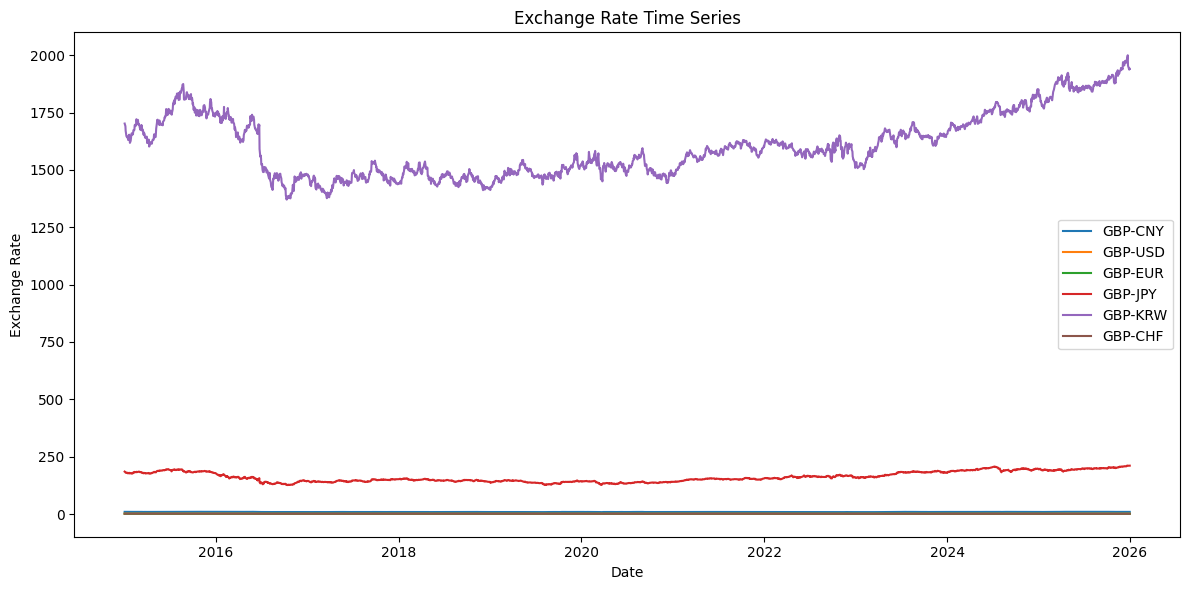

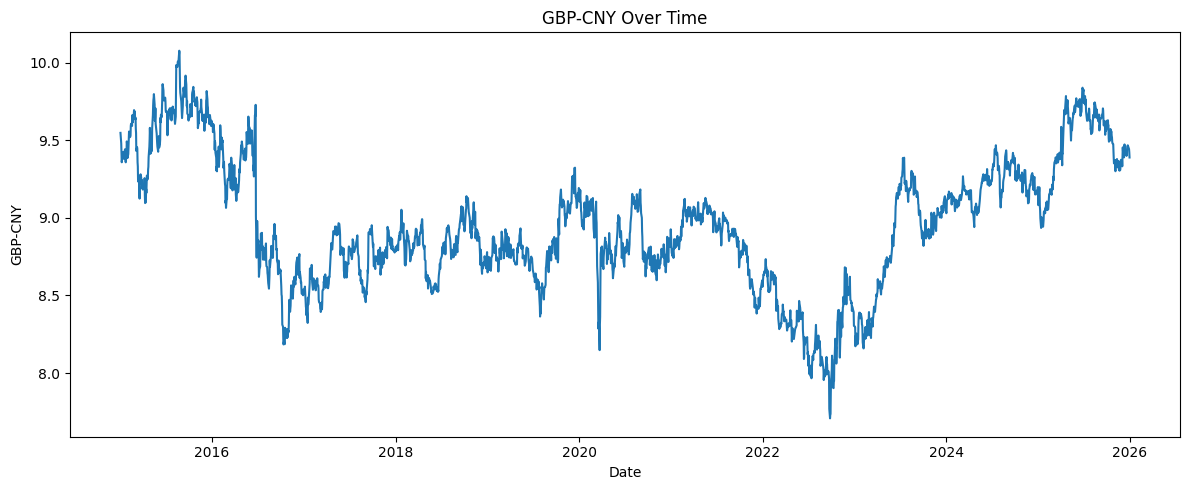

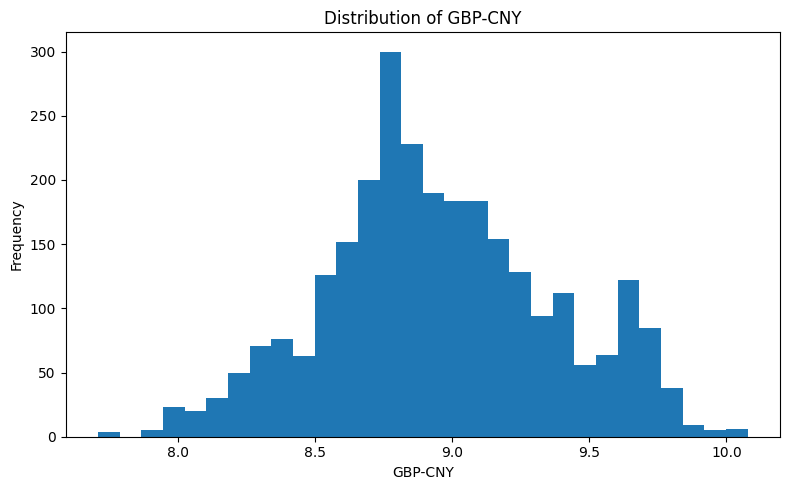

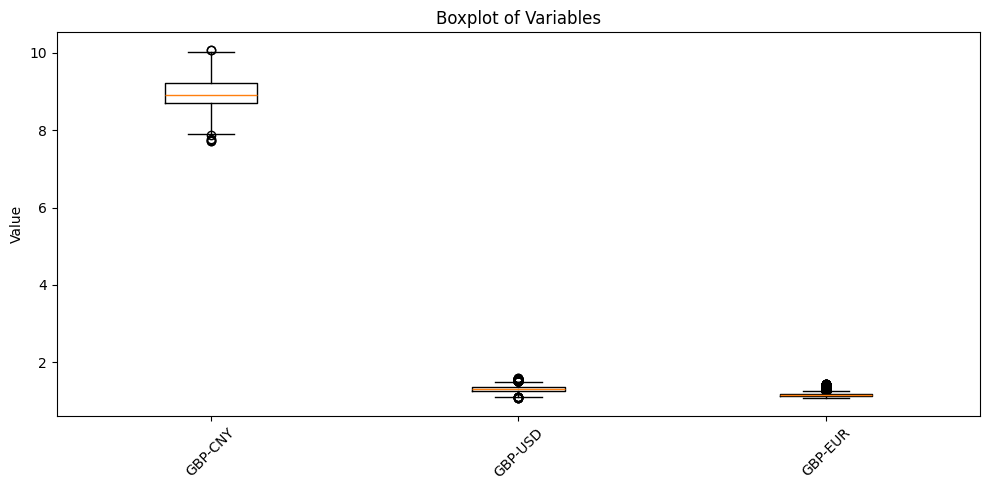

In [13]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(df)
plot_all_series(df)
plot_target_series(df, TARGET)
plot_histogram(df, TARGET)
plot_boxplot(df, cols=feature_columns[:3])

## Model Training

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 50
BATCH_SIZE = 64


In [15]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=X_train.shape[-1],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=5
)

Epoch 1/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 237.22it/s]


Epoch 1/50 | Train Loss: 0.4410 | Val Loss: 0.1469 | Train MAE: 0.4869 | Val MAE: 0.3028 | Train RMSE: 0.6257 | Val RMSE: 0.3423
Saved best model at epoch 1 with val loss 0.1469


Epoch 2/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 177.66it/s]


Epoch 2/50 | Train Loss: 0.0618 | Val Loss: 0.1025 | Train MAE: 0.1855 | Val MAE: 0.2804 | Train RMSE: 0.2436 | Val RMSE: 0.3023
Saved best model at epoch 2 with val loss 0.1025


Epoch 3/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 214.65it/s]


...

Epoch 13/50 | Train Loss: 0.0198 | Val Loss: 0.0335 | Train MAE: 0.1061 | Val MAE: 0.1396 | Train RMSE: 0.1387 | Val RMSE: 0.1608


Epoch 14/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 215.85it/s]


Epoch 14/50 | Train Loss: 0.0191 | Val Loss: 0.0317 | Train MAE: 0.1037 | Val MAE: 0.1356 | Train RMSE: 0.1366 | Val RMSE: 0.1581


Epoch 15/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 218.82it/s]

Epoch 15/50 | Train Loss: 0.0186 | Val Loss: 0.0368 | Train MAE: 0.1011 | Val MAE: 0.1441 | Train RMSE: 0.1347 | Val RMSE: 0.1660
Early stopping at epoch 15
Best model was from epoch 10 with val loss 0.0258


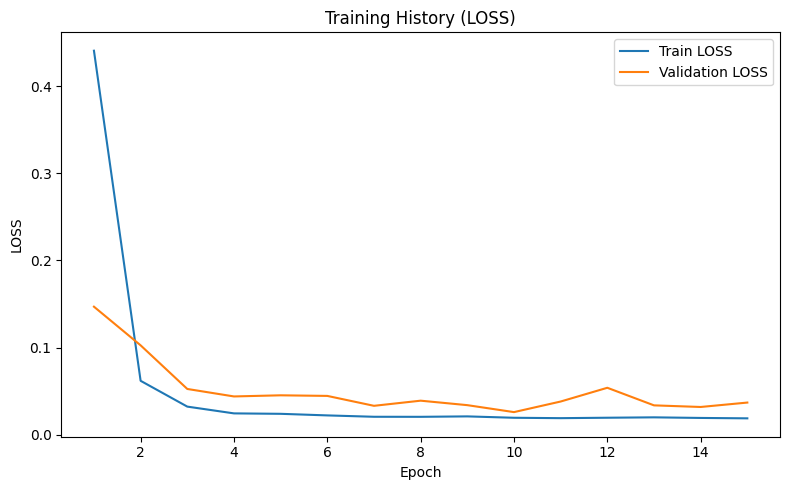

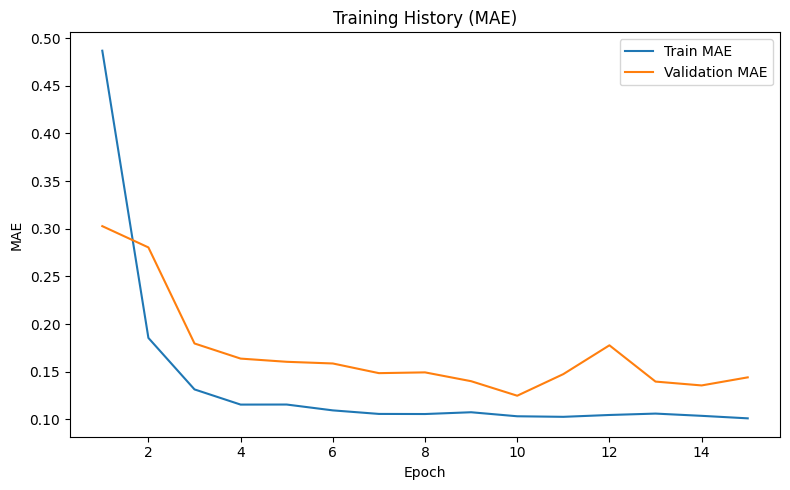

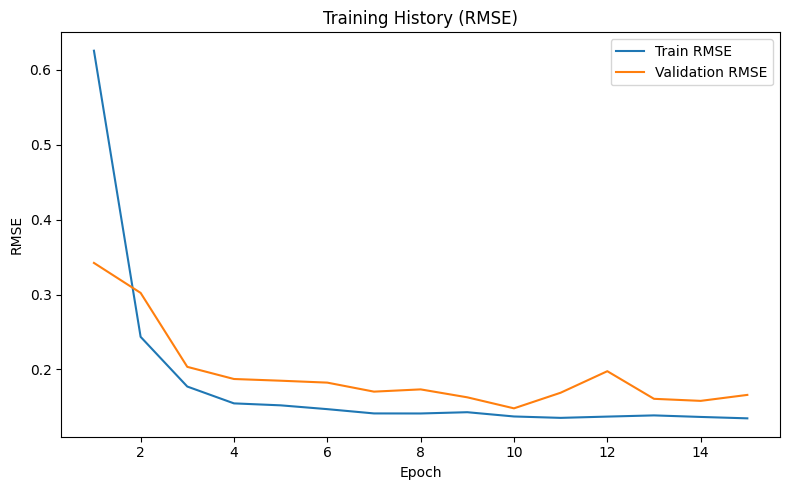

In [18]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 

In [19]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

plot_predictions(
    preds=preds_original,
    targets=targets_original,
    train_targets=y_train_original
)


Evaluation metrics:
MSE: 0.037497
RMSE: 0.193642
MAE: 0.143203


ValueError: operands could not be broadcast together with shapes (526,6) (12,) (526,6) 

In [20]:
print("X_train_t shape:", X_train_t.shape)
print("y_train_t shape:", y_train_t.shape)
print("X_test_t shape:", X_test_t.shape)
print("y_test_t shape:", y_test_t.shape)

# optional: inspect one sample
print("First X sample shape:", X_test_t[0].shape)
print("First y sample:", y_test_t[0])

X_train_t shape: torch.Size([2192, 30, 12])
y_train_t shape: torch.Size([2192])
X_test_t shape: torch.Size([526, 30, 12])
y_test_t shape: torch.Size([526])
First X sample shape: torch.Size([30, 12])
First y sample: tensor(0.4106)


In [29]:
import torch

# set this to the feature column that matches y
TARGET_COL = 0   

# naive baseline: predict next day = today
y_pred_naive = X_test_t[:, -1, TARGET_COL]

# metrics
mae = torch.mean(torch.abs(y_test_t - y_pred_naive)).item()
rmse = torch.sqrt(torch.mean((y_test_t - y_pred_naive) ** 2)).item()

print("Naive baseline MAE:", mae)
print("Naive baseline RMSE:", rmse)

Naive baseline MAE: 0.06873448938131332
Naive baseline RMSE: 0.09169762581586838
